<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/SdelOrbeDocs/DEEPLearn_Basic_2025_Begining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejemplo de CNN para reconocimiento de dígitos manuscritos
Este ejemplo es ideal para principiantes, ya que muestra el proceso completo: cargar los datos, preprocesarlos, definir la arquitectura del modelo, entrenarlo y evaluarlo.

Se empleara el Kera dataset automatico** "MNIST"**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


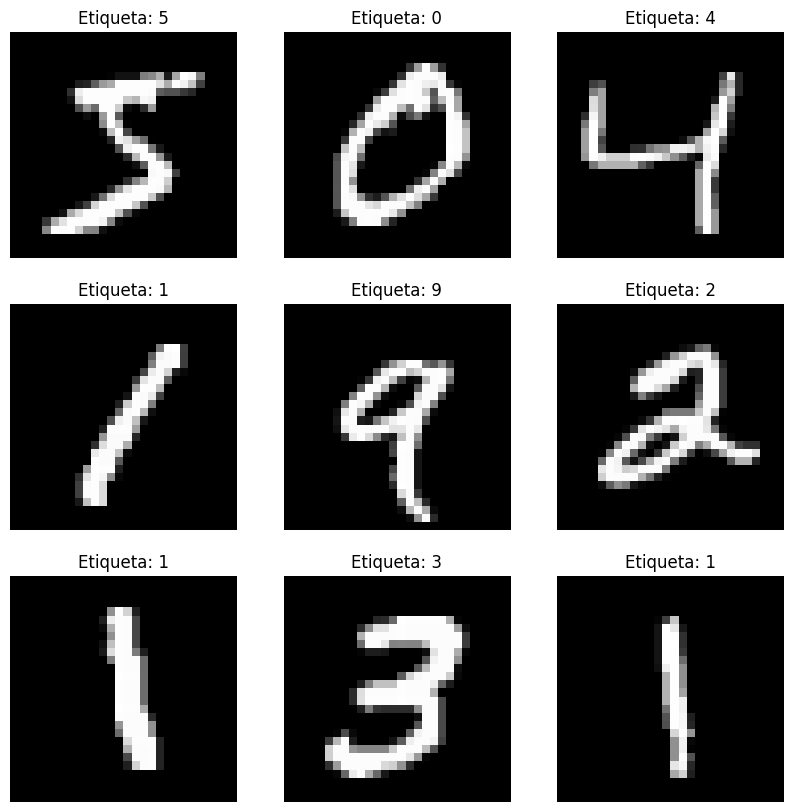

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.8947 - loss: 0.3429 - val_accuracy: 0.9844 - val_loss: 0.0501
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9840 - val_loss: 0.0518
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9895 - loss: 0.0327 - val_accuracy: 0.9889 - val_loss: 0.0351
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9925 - loss: 0.0236 - val_accuracy: 0.9878 - val_loss: 0.0385
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9943 - loss: 0.0193 - val_accuracy: 0.9902 - val_loss: 0.0324
313/313 - 3s - 8ms/step - accuracy: 0.9902 - loss: 0.0324

Precisión en los datos de prueba: 0.9902


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1.- Cargar el conjunto de datos MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2.- Normalizar los valores de los píxeles de 0 a 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3.- Reformar los datos para adaptarlos a la entrada de la CNN
# Las imágenes en MNIST son de 28x28 píxeles. La CNN espera un canal de color
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 4.- presentar algunas imagenes del entrenamiento
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')
plt.show()

# 5.-  Definir el modelo CNN
model = models.Sequential([
    # Primera capa convolucional y de max pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional y de max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Tercera capa convolucional
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Capa para aplanar los datos
    layers.Flatten(),

    # Capas densas para la clasificación
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 clases para los dígitos del 0 al 9
])

# 5.4 Mostrar el resumen de la arquitectura del modelo
model.summary()

# 6.- Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6.1 Entrenar el modelo con los datos de entrenamiento
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))
# 7.- Evaluar el modelo en los datos de prueba
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nPrecisión en los datos de prueba: {test_acc:.4f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
La imagen real era: 1
El modelo predijo: 1


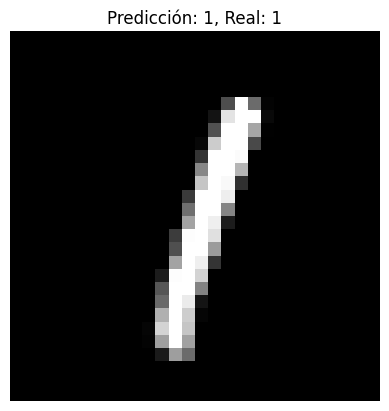

In [ ]:
# 8.-  Tomar una imagen del conjunto de prueba
imagen_a_probar = x_test[5]
etiqueta_verdadera = y_test[5]

# El modelo espera un lote de imágenes, no una sola, así que añadimos una dimensión
imagen_a_probar = np.expand_dims(imagen_a_probar, axis=0)

# Predecir la clase
prediccion = model.predict(imagen_a_probar)
prediccion_clase = np.argmax(prediccion)

print(f"La imagen real era: {etiqueta_verdadera}")
print(f"El modelo predijo: {prediccion_clase}")

# Opcional: Visualizar la imagen y el resultado
plt.imshow(x_test[5], cmap='gray')
plt.title(f"Predicción: {prediccion_clase}, Real: {etiqueta_verdadera}")
plt.axis('off')
plt.show()